# EDA: Gemini BTC Prediction Market Mispricing

Objectives:
1. Characterize the backtestable universe (1,292 contracts with candles + settlements)
2. Validate settlement outcomes against spot BTC price
3. Detect naive mispricing: do last-traded prices predict outcomes better than chance?
4. Understand market microstructure (liquidity, spreads, activity by time-to-expiry)
5. First-pass Black-Scholes fair value vs. market price

Settlement note: outcomes verified against KK_BRR_BTCUSD (CME CF Bitcoin Reference Rate), not raw Gemini spot.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

DATA = Path('../data/gemini_prediction_markets')
SPOT = Path('../data/gemini_spot')

## 1. Load Data

In [2]:
# Settlements
settlements = pd.read_csv(DATA / 'settlements.csv', parse_dates=['expiry', 'resolved_at'])
settlements['outcome'] = pd.to_numeric(settlements['outcome'], errors='coerce')
settlements['strike'] = pd.to_numeric(settlements['strike'], errors='coerce')
settlements = settlements.dropna(subset=['strike'])  # keep only HI-format contracts
# Strip timezone so timestamps are comparable with spot data (all UTC, tz-naive)
for col in ('expiry', 'resolved_at'):
    if settlements[col].dt.tz is not None:
        settlements[col] = settlements[col].dt.tz_localize(None)
print(f"Settlements (HI format): {len(settlements):,}")
print(f"  outcome=1: {settlements['outcome'].eq(1).sum():,}")
print(f"  outcome=0: {settlements['outcome'].eq(0).sum():,}")
print(f"  date range: {settlements['expiry'].min().date()} → {settlements['expiry'].max().date()}")
settlements.head(3)

Settlements (HI format): 5,556
  outcome=1: 2,662
  outcome=0: 2,894
  date range: 2026-01-26 → 2026-03-03


,instrument,event_ticker,expiry,resolved_at,strike,outcome,resolution_side
0,GEMI-BTC2602140800-HI62500,BTC2602140800,2026-02-14 08:00:00,2026-02-14 08:07:55.703,62500.0,1,yes
1,GEMI-BTC2602140800-HI65000,BTC2602140800,2026-02-14 08:00:00,2026-02-14 08:07:56.036,65000.0,1,yes
2,GEMI-BTC2602140800-HI67500,BTC2602140800,2026-02-14 08:00:00,2026-02-14 08:07:55.813,67500.0,1,yes


In [3]:
# Candles — load combined file, keep only settled HI contracts
settled_instruments = set(settlements['instrument'])

candles_raw = pd.read_csv(
    DATA / 'combined_candles.csv',
    dtype={'instrument': str},
    parse_dates=False
)
candles_raw['timestamp'] = pd.to_datetime(candles_raw['timestamp_ms'], unit='ms', utc=True)
candles_raw['timestamp'] = candles_raw['timestamp'].dt.tz_localize(None)  # strip tz for simplicity
candles = candles_raw[candles_raw['instrument'].isin(settled_instruments)].copy()
print(f"Candle rows for settled instruments: {len(candles):,}")
print(f"Unique instruments with candles: {candles['instrument'].nunique():,}")

Candle rows for settled instruments: 1,434,406
Unique instruments with candles: 1,292


In [4]:
# Spot BTC composite
spot = pd.read_csv(SPOT / 'BTCUSD_composite.csv')
spot['timestamp'] = pd.to_datetime(spot['datetime_utc'])
spot = spot.sort_values('timestamp').reset_index(drop=True)
print(f"Spot rows: {len(spot):,}")
print(f"  range: {spot['timestamp'].min()} → {spot['timestamp'].max()}")
spot.head(3)

Spot rows: 5,705
  range: 2025-03-03 00:00:00 → 2026-03-03 06:09:00


,timestamp_ms,datetime_utc,open,high,low,close,volume,source_tf_min,timestamp
0,1740960000000,2025-03-03 00:00:00,94271.45,94421.05,85065.37,86144.67,1471.095306,1440,2025-03-03
1,1741046400000,2025-03-04 00:00:00,86144.67,88944.60,81425.29,87212.50,1341.253249,1440,2025-03-04
2,1741132800000,2025-03-05 00:00:00,87212.50,91000.00,86307.89,90602.69,1463.405271,1440,2025-03-05


## 2. Backtestable Universe

In [5]:
# Instruments with both settlement AND candle data
instruments_with_candles = set(candles['instrument'].unique())
universe = settlements[settlements['instrument'].isin(instruments_with_candles)].copy()
print(f"Backtestable universe: {len(universe):,} contracts")
print(f"  outcome=1 (paid):    {universe['outcome'].eq(1).sum():,}")
print(f"  outcome=0 (lapsed):  {universe['outcome'].eq(0).sum():,}")

# Candle count per instrument
candle_counts = candles.groupby('instrument').size().rename('n_candles')
universe = universe.merge(candle_counts, on='instrument', how='left')

# Trade volume per instrument (use candle volume sum)
vol_sum = candles.groupby('instrument')['volume'].sum().rename('total_volume')
universe = universe.merge(vol_sum, on='instrument', how='left')

print(f"\nCandle count per instrument:")
print(universe['n_candles'].describe().round(1))
print(f"\nTotal volume per instrument:")
print(universe['total_volume'].describe().round(2))

Backtestable universe: 1,292 contracts
  outcome=1 (paid):    575
  outcome=0 (lapsed):  717

Candle count per instrument:
count    1292.0
mean     1110.2
std      1729.1
min         2.0
25%        22.0
50%        24.0
75%      4032.0
max      4032.0
Name: n_candles, dtype: float64

Total volume per instrument:
count      1292.00
mean       4546.67
std        8604.84
min           0.00
25%           0.00
50%        1250.00
75%        5814.00
max      125356.00
Name: total_volume, dtype: float64


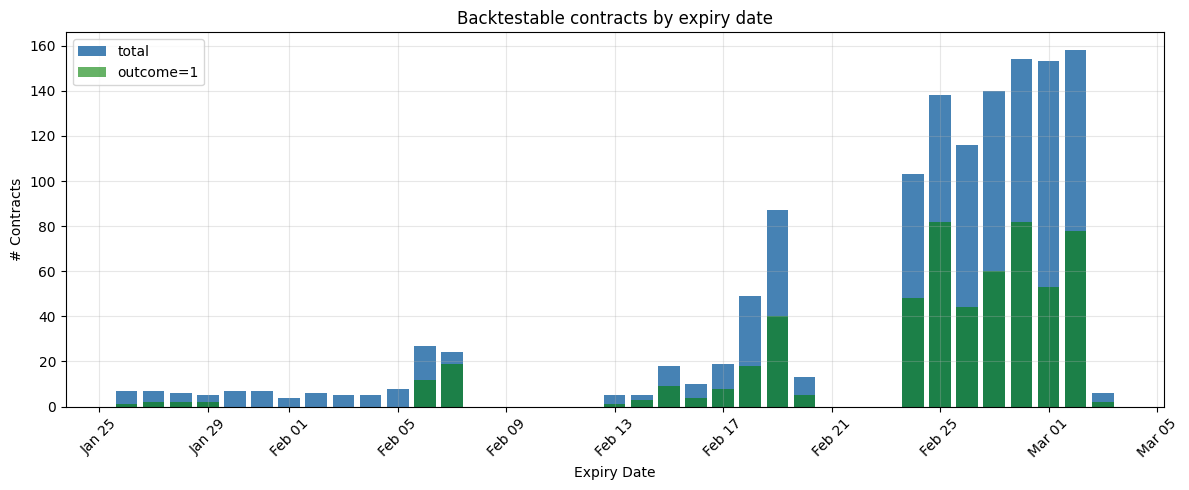

expiry_date  n_contracts  n_paid
 2026-01-26            7       1
 2026-01-27            7       2
 2026-01-28            6       2
 2026-01-29            5       2
 2026-01-30            7       0
 2026-01-31            7       0
 2026-02-01            4       0
 2026-02-02            6       0
 2026-02-03            5       0
 2026-02-04            5       0
 2026-02-05            8       0
 2026-02-06           27      12
 2026-02-07           24      19
 2026-02-13            5       1
 2026-02-14            5       3
 2026-02-15           18       9
 2026-02-16           10       4
 2026-02-17           19       8
 2026-02-18           49      18
 2026-02-19           87      40
 2026-02-20           13       5
 2026-02-24          103      48
 2026-02-25          138      82
 2026-02-26          116      44
 2026-02-27          140      60
 2026-02-28          154      82
 2026-03-01          153      53
 2026-03-02          158      78
 2026-03-03            6       2


In [6]:
# Contracts by expiry date
universe['expiry_date'] = universe['expiry'].dt.date
by_date = universe.groupby('expiry_date').agg(
    n_contracts=('instrument', 'count'),
    n_paid=('outcome', lambda x: (x == 1).sum()),
).reset_index()

fig, ax = plt.subplots()
ax.bar(pd.to_datetime(by_date['expiry_date']), by_date['n_contracts'], color='steelblue', label='total')
ax.bar(pd.to_datetime(by_date['expiry_date']), by_date['n_paid'], color='green', alpha=0.6, label='outcome=1')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.xticks(rotation=45)
ax.set_xlabel('Expiry Date')
ax.set_ylabel('# Contracts')
ax.set_title('Backtestable contracts by expiry date')
ax.legend()
plt.tight_layout()
plt.show()
print(by_date.to_string(index=False))

## 3. Settlement Validation — BTC Price at Expiry

In [7]:
def get_spot_at(ts, spot_df, window_min=30):
    """
    Find the closest spot price to timestamp ts within window_min minutes.
    Returns (close_price, lag_minutes) or (NaN, NaN) if not found.
    """
    window = pd.Timedelta(minutes=window_min)
    mask = (spot_df['timestamp'] >= ts - window) & (spot_df['timestamp'] <= ts + window)
    subset = spot_df[mask]
    if subset.empty:
        return np.nan, np.nan
    idx = (subset['timestamp'] - ts).abs().idxmin()
    row = subset.loc[idx]
    lag = abs((row['timestamp'] - ts).total_seconds() / 60)
    return row['close'], lag


# Map spot price at expiry to universe
spot_at_expiry = []
for _, row in universe.iterrows():
    price, lag = get_spot_at(row['expiry'], spot)
    spot_at_expiry.append({'instrument': row['instrument'], 'spot_at_expiry': price, 'spot_lag_min': lag})

spot_df = pd.DataFrame(spot_at_expiry)
universe = universe.merge(spot_df, on='instrument', how='left')

found = universe['spot_at_expiry'].notna().sum()
print(f"Spot price found at expiry: {found}/{len(universe)} contracts")
print(f"Median lag to nearest candle: {universe['spot_lag_min'].median():.1f} min")

Spot price found at expiry: 1292/1292 contracts
Median lag to nearest candle: 0.0 min


In [8]:
# Validate: does spot_at_expiry > strike match outcome?
u = universe.dropna(subset=['spot_at_expiry'])
naive_prediction = (u['spot_at_expiry'] > u['strike']).astype(int)
accuracy = (naive_prediction == u['outcome']).mean()
print(f"Spot-based settlement prediction accuracy: {accuracy:.1%}")
print("(100% = our spot data perfectly tracks the KK_BRR_BTCUSD settlement index)")

# Show mismatches — these reveal BRR vs Gemini spot divergence
mismatches = u[naive_prediction != u['outcome']].copy()
mismatches['spot_distance_pct'] = (mismatches['spot_at_expiry'] - mismatches['strike']) / mismatches['strike'] * 100
print(f"\nMismatches: {len(mismatches)}")
if len(mismatches) > 0:
    print(f"  Spot distance from strike at mismatch (pct):")
    print(mismatches['spot_distance_pct'].describe().round(3))
    print("\nSample mismatches (likely near-the-money at expiry):")
    print(mismatches[['instrument', 'strike', 'spot_at_expiry', 'outcome', 'spot_distance_pct']]
          .sort_values('spot_distance_pct', key=abs).head(10).to_string(index=False))

Spot-based settlement prediction accuracy: 94.2%
(100% = our spot data perfectly tracks the KK_BRR_BTCUSD settlement index)

Mismatches: 75
  Spot distance from strike at mismatch (pct):
count    75.000
mean      0.010
std       0.257
min      -0.759
25%      -0.094
50%       0.011
75%       0.132
max       0.712
Name: spot_distance_pct, dtype: float64

Sample mismatches (likely near-the-money at expiry):
                instrument  strike  spot_at_expiry  outcome  spot_distance_pct
GEMI-BTC2602260100-HI68500 68500.0        68502.00        0           0.002920
GEMI-BTC2602281600-HI64750 64750.0        64745.35        1          -0.007181
GEMI-BTC2602241900-HI64500 64500.0        64506.89        0           0.010682
GEMI-BTC2602270300-HI67250 67250.0        67242.02        1          -0.011866
GEMI-BTC2602241800-HI64250 64250.0        64261.66        0           0.018148
GEMI-BTC2602191400-HI66000 66000.0        66012.07        0           0.018288
GEMI-BTC2603020400-HI66750 66750.0    

## 4. Last-Traded Price as a Probability Estimate

In [9]:
# For each instrument, find the last candle close before expiry
last_prices = []
for inst, group in candles.groupby('instrument'):
    expiry = universe.loc[universe['instrument'] == inst, 'expiry'].iloc[0]
    before_expiry = group[group['timestamp'] < expiry]
    if before_expiry.empty:
        continue
    last_row = before_expiry.sort_values('timestamp').iloc[-1]
    last_prices.append({
        'instrument': inst,
        'last_price': last_row['close'],
        'last_volume': last_row['volume'],
        'last_timestamp': last_row['timestamp'],
    })

last_df = pd.DataFrame(last_prices)
universe = universe.merge(last_df, on='instrument', how='left')

# Minutes before expiry of last trade
universe['mins_before_expiry'] = (universe['expiry'] - universe['last_timestamp']).dt.total_seconds() / 60

print(f"Instruments with last price: {last_df['instrument'].nunique():,}")
print(f"\nLast trade timing before expiry (minutes):")
print(universe['mins_before_expiry'].describe().round(1))

Instruments with last price: 968

Last trade timing before expiry (minutes):
count    968.0
mean       5.2
std        2.0
min        5.0
25%        5.0
50%        5.0
75%        5.0
max       30.0
Name: mins_before_expiry, dtype: float64


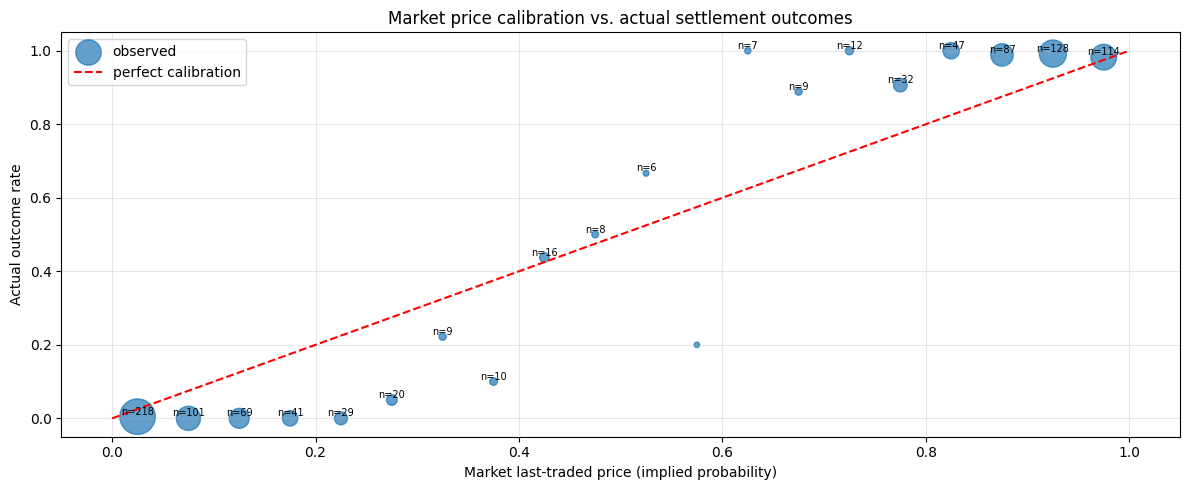

bin_mid   n  actual_prob
  0.025 218     0.004587
  0.075 101     0.000000
  0.125  69     0.000000
  0.175  41     0.000000
  0.225  29     0.000000
  0.275  20     0.050000
  0.325   9     0.222222
  0.375  10     0.100000
  0.425  16     0.437500
  0.475   8     0.500000
  0.525   6     0.666667
  0.575   5     0.200000
  0.625   7     1.000000
  0.675   9     0.888889
  0.725  12     1.000000
  0.775  32     0.906250
  0.825  47     1.000000
  0.875  87     0.988506
  0.925 128     0.992188
  0.975 114     0.982456


In [10]:
# Calibration plot: does market price predict outcome?
u2 = universe.dropna(subset=['last_price', 'outcome'])

# Bin by last price
bins = np.arange(0, 1.05, 0.05)
u2['price_bin'] = pd.cut(u2['last_price'], bins=bins)
cal = u2.groupby('price_bin', observed=True).agg(
    n=('outcome', 'count'),
    actual_prob=('outcome', 'mean')
).reset_index()
cal['bin_mid'] = cal['price_bin'].apply(lambda x: x.mid)

fig, ax = plt.subplots()
ax.scatter(cal['bin_mid'], cal['actual_prob'], s=cal['n'] * 3, alpha=0.7, label='observed')
ax.plot([0, 1], [0, 1], 'r--', label='perfect calibration')
for _, row in cal.iterrows():
    if row['n'] > 5:
        ax.annotate(f"n={int(row['n'])}", (row['bin_mid'], row['actual_prob']),
                    fontsize=7, ha='center', va='bottom')
ax.set_xlabel('Market last-traded price (implied probability)')
ax.set_ylabel('Actual outcome rate')
ax.set_title('Market price calibration vs. actual settlement outcomes')
ax.legend()
plt.tight_layout()
plt.show()
print(cal[['bin_mid', 'n', 'actual_prob']].to_string(index=False))

In [11]:
# Brier score — lower is better; 0.25 = random, 0 = perfect
brier = ((u2['last_price'] - u2['outcome']) ** 2).mean()
brier_naive = 0.25  # always predict 0.5
print(f"Brier score (market price): {brier:.4f}")
print(f"Brier score (naive 0.5):    {brier_naive:.4f}")
print(f"Skill score: {1 - brier / brier_naive:.3f}  (>0 = better than naive)")

Brier score (market price): 0.0341
Brier score (naive 0.5):    0.2500
Skill score: 0.864  (>0 = better than naive)


## 5. Mispricing — Naive Black-Scholes Fair Value

In [12]:
from scipy.stats import norm


def bs_binary_call(S, K, T, r, sigma):
    """
    Black-Scholes cash-or-nothing binary call price.
    Pays $1 if S(T) > K.
    P = e^{-rT} * N(d2)
    """
    if T <= 0 or sigma <= 0 or S <= 0:
        return np.nan
    d2 = (np.log(S / K) + (r - 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
    return np.exp(-r * T) * norm.cdf(d2)


def rolling_realized_vol(spot_df, as_of, window_days=30):
    """
    Annualized realized vol from 30-day window of log returns before as_of.
    """
    cutoff = as_of - pd.Timedelta(days=window_days)
    subset = spot_df[(spot_df['timestamp'] >= cutoff) & (spot_df['timestamp'] < as_of)]
    if len(subset) < 10:
        return np.nan
    log_ret = np.diff(np.log(subset['close'].values))
    # Annualize: depends on candle frequency (source_tf_min)
    # Use mean candle spacing
    dt_min = (subset['timestamp'].diff().dt.total_seconds().median()) / 60
    periods_per_year = 525600 / dt_min
    return np.std(log_ret) * np.sqrt(periods_per_year)


print("Computing BS fair values... (may take ~30s)")

r = 0.045  # approximate risk-free rate (US 1yr Treasury, early 2026)
results = []

# Compute on universe with last_price available
u3 = universe.dropna(subset=['last_price', 'last_timestamp', 'spot_at_expiry']).copy()

for _, row in u3.iterrows():
    # Use spot price at time of last trade
    S_price, _ = get_spot_at(row['last_timestamp'], spot, window_min=60)
    if np.isnan(S_price):
        results.append(np.nan)
        continue

    T = (row['expiry'] - row['last_timestamp']).total_seconds() / (365.25 * 86400)
    sigma = rolling_realized_vol(spot, row['last_timestamp'], window_days=30)

    fair = bs_binary_call(S_price, row['strike'], T, r, sigma)
    results.append(fair)

u3 = u3.copy()
u3['bs_fair'] = results
u3['mispricing'] = u3['last_price'] - u3['bs_fair']  # positive = market overpriced

valid = u3.dropna(subset=['bs_fair'])
print(f"Valid BS valuations: {len(valid)}")
print(f"\nMispricing (market - BS fair):")
print(valid['mispricing'].describe().round(4))

Computing BS fair values... (may take ~30s)
Valid BS valuations: 968

Mispricing (market - BS fair):
count    968.0000
mean       0.0038
std        0.1652
min       -0.6500
25%       -0.0785
50%        0.0054
75%        0.0700
max        0.9900
Name: mispricing, dtype: float64


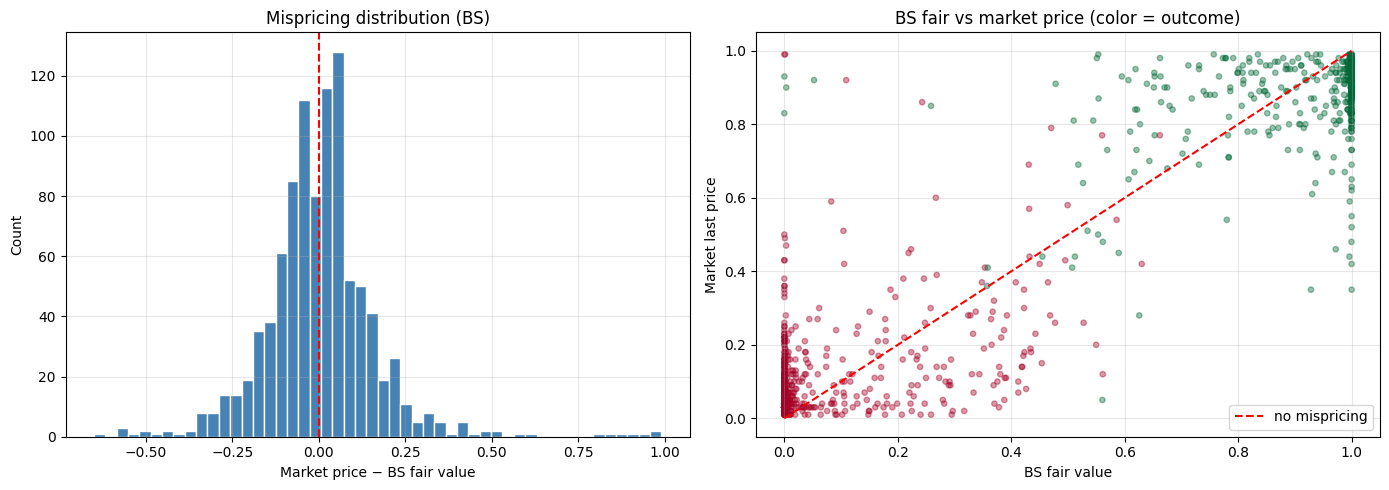

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Mispricing distribution
axes[0].hist(valid['mispricing'], bins=50, color='steelblue', edgecolor='white')
axes[0].axvline(0, color='red', linestyle='--')
axes[0].set_xlabel('Market price − BS fair value')
axes[0].set_ylabel('Count')
axes[0].set_title('Mispricing distribution (BS)')

# BS fair vs market price
axes[1].scatter(valid['bs_fair'], valid['last_price'], alpha=0.4, s=15, c=valid['outcome'], cmap='RdYlGn')
axes[1].plot([0, 1], [0, 1], 'r--', label='no mispricing')
axes[1].set_xlabel('BS fair value')
axes[1].set_ylabel('Market last price')
axes[1].set_title('BS fair vs market price (color = outcome)')
axes[1].legend()

plt.tight_layout()
plt.show()

In [14]:
# Does mispricing predict outcome?
# Short when market > BS (mispricing > 0): expect outcome=0
# Long  when market < BS (mispricing < 0): expect outcome=1

threshold = 0.05  # 5 cent minimum edge

long_signals  = valid[valid['mispricing'] < -threshold]  # underpriced → buy
short_signals = valid[valid['mispricing'] >  threshold]  # overpriced  → sell

print(f"Signals with |mispricing| > {threshold}:")
print(f"  Long  (buy underpriced):  {len(long_signals)} trades")
print(f"    Win rate: {long_signals['outcome'].mean():.1%}")
print(f"  Short (sell overpriced):  {len(short_signals)} trades")
print(f"    Win rate (outcome=0): {(1-short_signals['outcome']).mean():.1%}")

all_signals = len(long_signals) + len(short_signals)
print(f"\nTotal signals: {all_signals} / {len(valid)} ({all_signals/len(valid):.1%} of universe)")

Signals with |mispricing| > 0.05:
  Long  (buy underpriced):  311 trades
    Win rate: 69.5%
  Short (sell overpriced):  295 trades
    Win rate (outcome=0): 70.2%

Total signals: 606 / 968 (62.6% of universe)


## 6. Market Microstructure

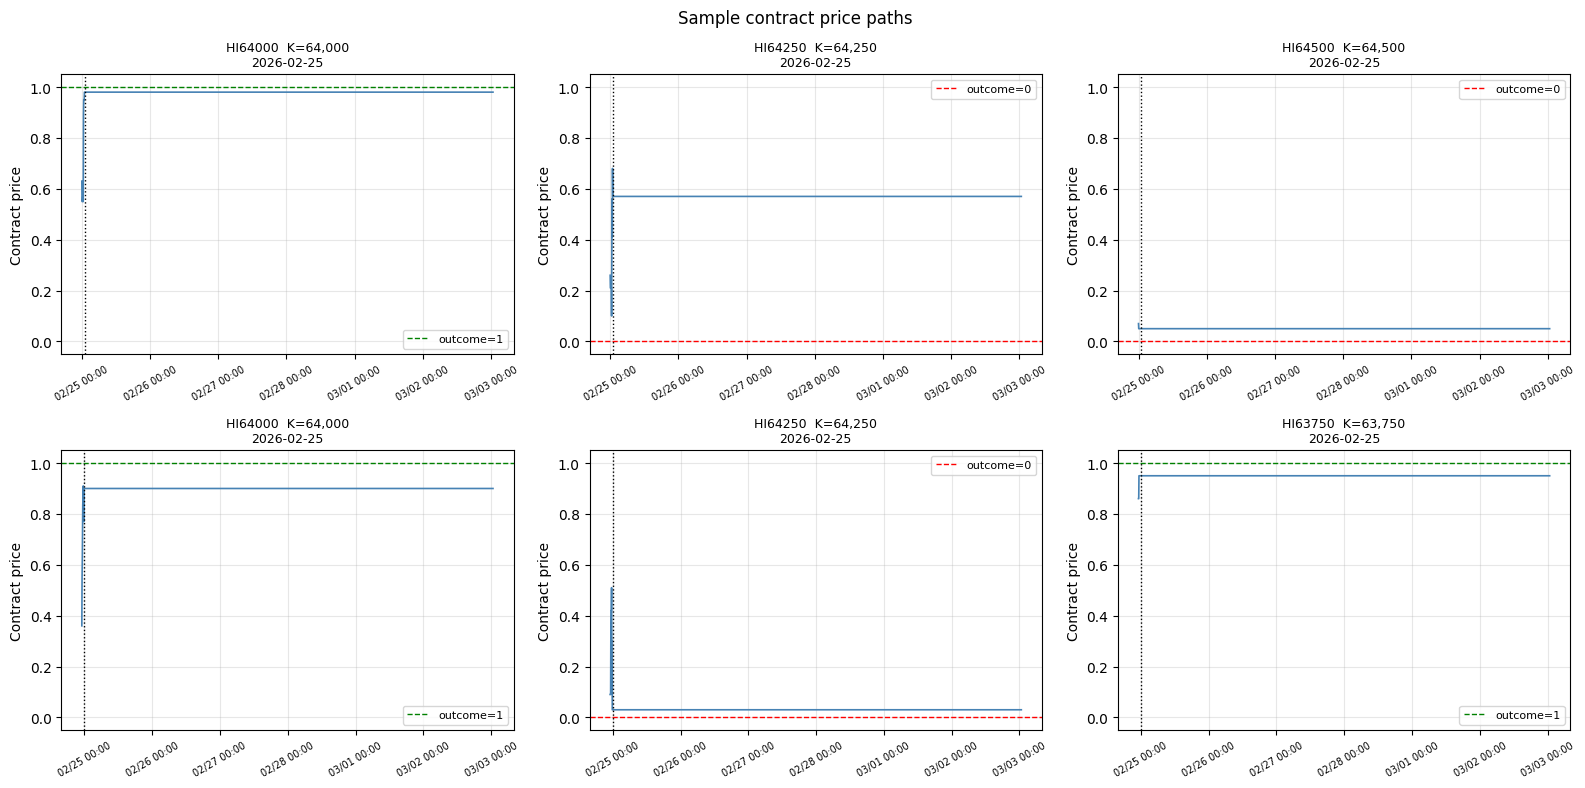

In [15]:
# Trading activity over the contract lifetime
# Pick a few representative contracts and plot candle activity

# Select 3 contracts with good activity (many candles)
sample_instruments = (
    universe.dropna(subset=['last_price'])
    .nlargest(6, 'n_candles')['instrument'].tolist()
)

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for ax, inst in zip(axes, sample_instruments):
    row = universe[universe['instrument'] == inst].iloc[0]
    c = candles[candles['instrument'] == inst].sort_values('timestamp')
    ax.plot(c['timestamp'], c['close'], lw=1.2, color='steelblue')
    ax.axhline(row['outcome'], color='green' if row['outcome'] == 1 else 'red',
               linestyle='--', lw=1, label=f"outcome={int(row['outcome'])}")
    ax.axvline(row['expiry'], color='black', linestyle=':', lw=1)
    strike_label = f"K={int(row['strike']):,}"
    ax.set_title(f"{inst.split('-')[-1]}  {strike_label}\n{row['expiry'].date()}", fontsize=9)
    ax.set_ylabel('Contract price')
    ax.set_ylim(-0.05, 1.05)
    ax.legend(fontsize=8)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m/%d %H:%M'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, fontsize=7)

plt.suptitle('Sample contract price paths', fontsize=12)
plt.tight_layout()
plt.show()

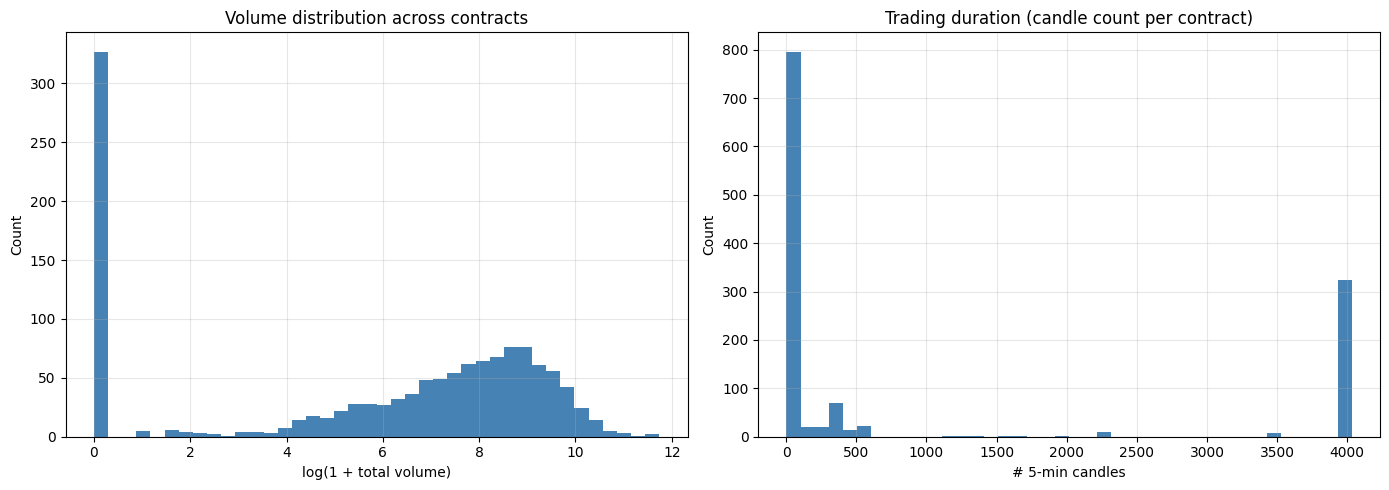

Median candles per contract: 24
Contracts with >100 candles: 497
Contracts with >500 candles: 374


In [16]:
# Volume distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(np.log1p(universe['total_volume'].dropna()), bins=40, color='steelblue')
axes[0].set_xlabel('log(1 + total volume)')
axes[0].set_ylabel('Count')
axes[0].set_title('Volume distribution across contracts')

axes[1].hist(universe['n_candles'].dropna(), bins=40, color='steelblue')
axes[1].set_xlabel('# 5-min candles')
axes[1].set_ylabel('Count')
axes[1].set_title('Trading duration (candle count per contract)')

plt.tight_layout()
plt.show()

print(f"Median candles per contract: {universe['n_candles'].median():.0f}")
print(f"Contracts with >100 candles: {(universe['n_candles'] > 100).sum()}")
print(f"Contracts with >500 candles: {(universe['n_candles'] > 500).sum()}")

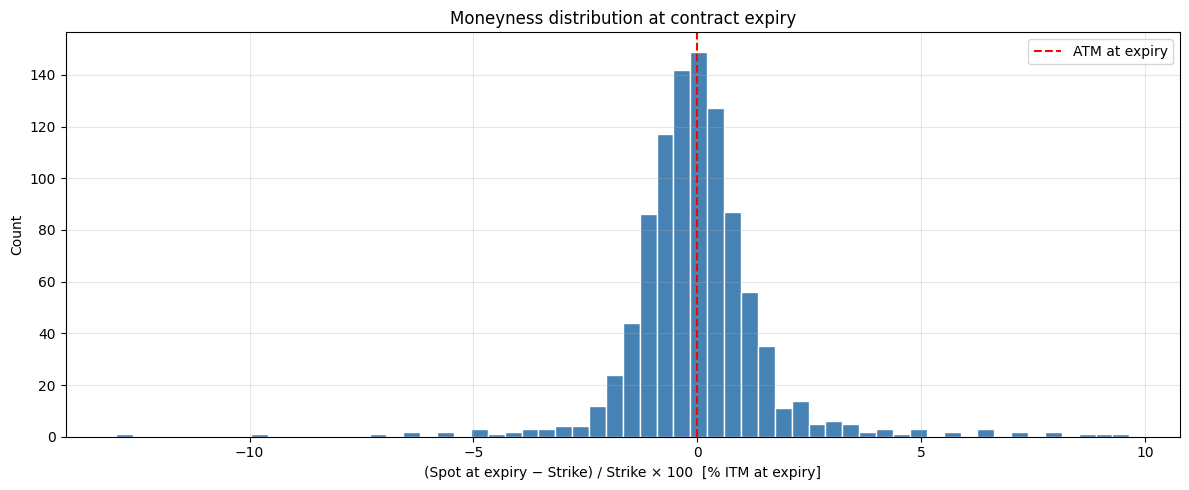

In [17]:
# Strike distance from spot at last trade
u3['moneyness'] = (u3['spot_at_expiry'] - u3['strike']) / u3['strike'] * 100  # % OTM/ITM at expiry

fig, ax = plt.subplots()
ax.hist(u3['moneyness'].dropna(), bins=60, color='steelblue', edgecolor='white')
ax.axvline(0, color='red', linestyle='--', label='ATM at expiry')
ax.set_xlabel('(Spot at expiry − Strike) / Strike × 100  [% ITM at expiry]')
ax.set_ylabel('Count')
ax.set_title('Moneyness distribution at contract expiry')
ax.legend()
plt.tight_layout()
plt.show()

## 7. Summary & Next Steps

In [18]:
print("="*60)
print("EDA SUMMARY")
print("="*60)
print(f"Backtestable universe:  {len(universe):,} contracts")
print(f"  outcome=1:            {universe['outcome'].eq(1).sum():,}")
print(f"  outcome=0:            {universe['outcome'].eq(0).sum():,}")
if 'bs_fair' in valid.columns:
    print(f"  BS valuations:        {len(valid):,}")
    print(f"  Mean |mispricing|:    {valid['mispricing'].abs().mean():.4f}")
    print(f"  Long signals (>5c):   {len(long_signals):,}")
    print(f"  Short signals (>5c):  {len(short_signals):,}")
print()
print("KEY QUESTIONS FROM EDA:")
print("  1. Are market prices well-calibrated? (See Section 4)")
print("  2. Is BS mispricing directionally predictive? (See Section 5)")
print("  3. How much of universe is liquid enough to trade? (See Section 6)")
print("  4. How large is BRR vs Gemini spot divergence? (See Section 3)")
print()
print("NEXT STEPS:")
print("  - Phase 1: Build Bates pricer (COS method + Monte Carlo)")
print("  - Phase 2: Historical calibration from spot returns")
print("  - Compare Bates vs BS fair values on this universe")

EDA SUMMARY
Backtestable universe:  1,292 contracts
  outcome=1:            575
  outcome=0:            717
  BS valuations:        968
  Mean |mispricing|:    0.1126
  Long signals (>5c):   311
  Short signals (>5c):  295

KEY QUESTIONS FROM EDA:
  1. Are market prices well-calibrated? (See Section 4)
  2. Is BS mispricing directionally predictive? (See Section 5)
  3. How much of universe is liquid enough to trade? (See Section 6)
  4. How large is BRR vs Gemini spot divergence? (See Section 3)

NEXT STEPS:
  - Phase 1: Build Bates pricer (COS method + Monte Carlo)
  - Phase 2: Historical calibration from spot returns
  - Compare Bates vs BS fair values on this universe
